In [1]:
import torch
import torchvision as tv
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
import torch.optim as optim
from torchvision import models

In [2]:
transform_train=transforms.Compose([
    transforms.Resize(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomCrop(224, padding=4),
    transforms.ToTensor()
])

transform_test=transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor()
])

# Reduced batch_size to 128 to avoid OutOfMemory errors on 224x224 images
trainset=tv.datasets.CIFAR10(root='./data', train=True, download=False, transform=transform_train)
trainloader=torch.utils.data.DataLoader(trainset, batch_size=200, shuffle=True,
                                        num_workers=2, pin_memory=True, persistent_workers=True)

testset=tv.datasets.CIFAR10(root='./data', train=False, download=False, transform=transform_test)
testloader=torch.utils.data.DataLoader(testset, batch_size=200, shuffle=False,
                                       num_workers=2, pin_memory=True, persistent_workers=True)
print(f'Dataset size: {len(trainset)}')

Dataset size: 50000


In [3]:
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


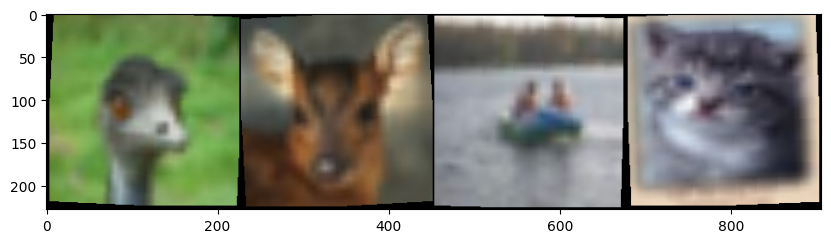

bird  deer  ship  cat  


In [4]:
def imshow(img):
    # Convert from torch.Tensor to numpy for plotting
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

# Get some random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# Show images (showing first 4 in the batch)
plt.figure(figsize=(10,10))
imshow(tv.utils.make_grid(images[:4]))
# Print labels
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(4)))

In [5]:
# ResNet-18 Model Structure
resnet_model = nn.Sequential(
    # Stem
    nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False),
    nn.BatchNorm2d(64),
    nn.ReLU(inplace=True),
    nn.MaxPool2d(kernel_size=3, stride=2, padding=1),

    # Simplified blocks
    nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1),
    nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1),

    nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
    nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1),

    nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1),
    nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1),

    nn.Conv2d(256, 512, kernel_size=3, stride=2, padding=1),
    nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1),

    nn.AdaptiveAvgPool2d((1, 1)),
    nn.Flatten(),
    nn.Linear(512, 10), # 10 output units for 10 CIFAR classes
    nn.Softmax(dim=1)
)

# Move to device
resnet_model = resnet_model.to(device)

# Pass images through the model to verify
images_gpu = images.to(device)
model_output = resnet_model(images_gpu)

print(f"Input batch shape: {images_gpu.shape}")
print(f"Output batch shape (10 classes): {model_output.shape}")

Input batch shape: torch.Size([200, 3, 224, 224])
Output batch shape (10 classes): torch.Size([200, 10])


In [6]:
class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_planes, planes, stride=1):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != self.expansion * planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, self.expansion * planes, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(self.expansion * planes)
            )

    def forward(self, x):
        out = torch.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = torch.relu(out)
        return out

# Create a small model just for the stem part as defined in the ResNet model
stem_extractor = nn.Sequential(
    nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False),
    nn.BatchNorm2d(64),
    nn.ReLU(inplace=True),
    nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
).to(device)

# Get the stem output using the images_gpu tensor from a previous cell
stem_output = stem_extractor(images_gpu)

# Test the BasicBlock with the stem output
block1 = BasicBlock(64, 64, stride=1).to(device)
block_output = block1(stem_output)
print(f"Stem output shape: {stem_output.shape}")
print(f"BasicBlock output shape: {block_output.shape}")

Stem output shape: torch.Size([200, 64, 56, 56])
BasicBlock output shape: torch.Size([200, 64, 56, 56])


In [7]:
class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_planes, planes, stride=1):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != self.expansion * planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, self.expansion * planes, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(self.expansion * planes)
            )

    def forward(self, x):
        out = torch.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = torch.relu(out)
        return out

class ResNet(nn.Module):
    def __init__(self, block, num_blocks, num_classes=10):
        super(ResNet, self).__init__()
        self.in_planes = 64

        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        self.layer1 = self._make_layer(block, 64, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 128, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 256, num_blocks[2], stride=2)
        self.layer4 = self._make_layer(block, 512, num_blocks[3], stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.linear = nn.Linear(512 * block.expansion, num_classes)

    def _make_layer(self, block, planes, num_blocks, stride):
        strides = [stride] + [1]*(num_blocks-1)
        layers = []
        for stride in strides:
            layers.append(block(self.in_planes, planes, stride))
            self.in_planes = planes * block.expansion
        return nn.Sequential(*layers)

    def forward(self, x):
        out = torch.relu(self.bn1(self.conv1(x)))
        out = self.maxpool(out)
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = self.avgpool(out)
        out = torch.flatten(out, 1)
        out = self.linear(out)
        return out

def ResNet18():
    return ResNet(BasicBlock, [2, 2, 2, 2])

# Instantiate the full ResNet-18 model
model = ResNet18().to(device)
print("ResNet-18 model successfully instantiated!")

ResNet-18 model successfully instantiated!


In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)

print(f"Loss Function: {criterion}")
print(f"Optimizer: {optimizer}")

Loss Function: CrossEntropyLoss()
Optimizer: SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.1
    maximize: False
    momentum: 0.9
    nesterov: False
    weight_decay: 0.0005
)


In [9]:
# Initialize GradScaler for mixed precision training
scaler = torch.amp.GradScaler('cuda')

def train(epoch):
    model.train()
    running_loss = 0.0
    for batch_idx, (inputs, targets) in enumerate(trainloader):
        inputs, targets = inputs.to(device, non_blocking=True), targets.to(device, non_blocking=True)

        optimizer.zero_grad()

        # Use autocast for mixed precision
        with torch.amp.autocast('cuda'):
            outputs = model(inputs)
            loss = criterion(outputs, targets)

        # 1. Scale the loss and call backward
        scaler.scale(loss).backward()

        # 2. scaler.step() first unscales the gradients of the optimizer's assigned parameters.
        # If these gradients do not contain infs or NaNs, optimizer.step() is then called,
        # otherwise, optimizer.step() is skipped.
        scaler.step(optimizer)

        # 3. Updates the scale for next iteration
        scaler.update()

        running_loss += loss.item()
        if batch_idx % 50 == 49:
            print(f'Epoch: {epoch} | Batch: {batch_idx + 1} | Loss: {running_loss / 50:.3f}')
            running_loss = 0.0

In [10]:
# Clear GPU cache before restarting
torch.cuda.empty_cache()

# Reset scheduler and run fixed training loop
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)
num_epochs = 10
print(f"Starting training for {num_epochs} epochs with Batch Size 128 and AMP...")
for epoch in range(1, num_epochs + 1):
    train(epoch)
    scheduler.step()
print("Training finished!")

Starting training for 10 epochs with Batch Size 128 and AMP...
Epoch: 1 | Batch: 50 | Loss: 3.078
Epoch: 1 | Batch: 100 | Loss: 2.076
Epoch: 1 | Batch: 150 | Loss: 1.949
Epoch: 1 | Batch: 200 | Loss: 1.851
Epoch: 1 | Batch: 250 | Loss: 1.748
Epoch: 2 | Batch: 50 | Loss: 1.672
Epoch: 2 | Batch: 100 | Loss: 1.603
Epoch: 2 | Batch: 150 | Loss: 1.513
Epoch: 2 | Batch: 200 | Loss: 1.497
Epoch: 2 | Batch: 250 | Loss: 1.449
Epoch: 3 | Batch: 50 | Loss: 1.388
Epoch: 3 | Batch: 100 | Loss: 1.351
Epoch: 3 | Batch: 150 | Loss: 1.287
Epoch: 3 | Batch: 200 | Loss: 1.262
Epoch: 3 | Batch: 250 | Loss: 1.219
Epoch: 4 | Batch: 50 | Loss: 1.146
Epoch: 4 | Batch: 100 | Loss: 1.091
Epoch: 4 | Batch: 150 | Loss: 1.079
Epoch: 4 | Batch: 200 | Loss: 1.028
Epoch: 4 | Batch: 250 | Loss: 0.975
Epoch: 5 | Batch: 50 | Loss: 0.921
Epoch: 5 | Batch: 100 | Loss: 0.901
Epoch: 5 | Batch: 150 | Loss: 0.865
Epoch: 5 | Batch: 200 | Loss: 0.837
Epoch: 5 | Batch: 250 | Loss: 0.810
Epoch: 6 | Batch: 50 | Loss: 0.766
Epoch: 

In [11]:
def test():
    model.eval() # Set the model to evaluation mode
    correct = 0
    total = 0
    with torch.no_grad(): # Disable gradient calculation during testing
        for inputs, targets in testloader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += targets.size(0)
            correct += (predicted == targets).sum().item()

    accuracy = 100 * correct / total
    print(f'Accuracy of the network on the 10000 test images: {accuracy:.2f}%')

# Run the test function
test()

Accuracy of the network on the 10000 test images: 81.90%


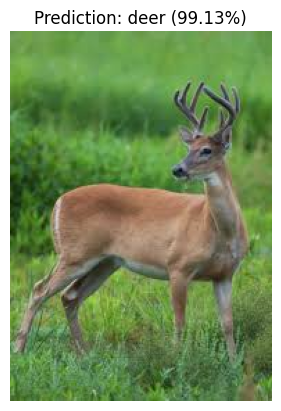

In [14]:
from PIL import Image
import torch.nn.functional as F

def predict_external_image(image_path):
    # Load the image
    img = Image.open(image_path).convert('RGB')

    # Apply the same transform as testloader
    img_t = transform_test(img)
    img_t = img_t.unsqueeze(0).to(device) # Add batch dimension and move to GPU

    model.eval()
    with torch.no_grad():
        output = model(img_t)
        # Get probabilities using softmax
        probs = F.softmax(output, dim=1)
        conf, predicted = torch.max(probs, 1)

    label = classes[predicted.item()]
    confidence = conf.item() * 100

    # Display result
    plt.imshow(img)
    plt.title(f'Prediction: {label} ({confidence:.2f}%)')
    plt.axis('off')
    plt.show()

# Predict using the uploaded file
predict_external_image('/content/images.jpg')